# 三個會改變物理結果的靜默缺陷：修正前後對照

這份 notebook 用**可以直接執行的實例**說明 `fix/core-silent-convention-bugs` 分支修正的三個缺陷。
每一節都同時跑「修正前」與「修正後」的程式碼，把數字並排給你看。

| 代號 | 缺陷 | 影響的功能 |
|---|---|---|
| **A** | Slater 行列式態製備的 Givens 旋轉角度反號，製備出**能量最高**而非最低的態 | `aqs polarization`、含 $\Delta U$ 的 `aqs berry`，以及所有依賴初態的實驗 |
| **B** | CUDA-Q 後端把 qiskit 的 qubit $i$ 錯映射到 CUDA-Q 的 qubit $n-1-i$ | **所有** `--backend cudaq` 的 GPU 結果 |
| **C** | `load_hamiltonian` 沒把 OpenFermion 的大端序轉成 qiskit 的小端序 | `aqs measure` 讀入 `fermion_operator` / `qubit_operator` 格式的**非對稱**哈密頓量 |

三者的共同特徵：**不拋例外、不產生 NaN、輸出看起來完全合理，只是物理是錯的**。
所以本文的每一個判斷都對照**獨立算出的參考值**（單粒子能譜、OpenFermion 直接建的行列式、陷阱位置），
不拿程式自己的舊輸出當標準。

## 「修正前」與「修正後」指的是什麼

- **修正前**：`main` 分支 `0fe9d1d` 的 `src/aqs/`。`origin/main` 上 `QCE26/src/aqs/` 目錄內的
  `core.py`、`hamiltonian.py`、`backends.py` 與這個版本**逐位元相同**，`QCE26/src/aqs/cudaq_core.py` 也用同樣的 $n-1-i$ 映射，
  所以下面所有「修正前」的結論同樣適用於 `QCE26/`。
- **修正後**：本 notebook 所在分支（執行時會印出 SHA）。

同一個 Python 行程不能同時 import 兩個版本的 `aqs`，因此本文把三段舊碼**逐字抄自 `0fe9d1d`**，
需要時暫時替換（monkeypatch）到現行模組裡，跑完立刻還原。你可以在每一節看到舊碼本身。

## 如何重跑

```bash
uv sync --extra cu12            # GPU 機器；CPU 機器用 uv sync
uv run --with jupyter jupyter lab docs/defect_report/defects_before_after.ipynb
```

沒有 CUDA-Q 也能跑完：缺陷 B 的核心論證只用 numpy，真實 GPU 的那一格會自動跳過。
執行完會把數字寫到 `results.json`、圖寫到 `figures/`，供 `defects_before_after.typ` 產生 PDF 摘要。

In [1]:
import os, sys, json, pathlib, contextlib, subprocess, tempfile, warnings
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1"); os.environ.setdefault("OMP_NUM_THREADS", "1")
warnings.filterwarnings("ignore")

import numpy as np
import openfermion as of
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

import aqs, aqs.core as core, aqs.hamiltonian as ham
from aqs.core import SSHHModel, build_annealing_circuit
from aqs.backends import get_backend, selftest
from aqs.experiments import polarization_sweep, fidelity_scan
from aqs.hamiltonian import load_hamiltonian, measure_hamiltonian
from aqs.observables import density_profile_qubits, density_profile

# 找到 repo 根目錄（examples/ 在那裡），輸出放在本 notebook 所在目錄
HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / "pyproject.toml").exists() and REPO != REPO.parent:
    REPO = REPO.parent
OUT_DIR = REPO / "docs" / "defect_report"
FIG_DIR = OUT_DIR / "figures"; FIG_DIR.mkdir(parents=True, exist_ok=True)

def git(*args):
    try: return subprocess.check_output(["git", *args], cwd=REPO, text=True).strip()
    except Exception: return "unknown"

results = {"meta": {"after_sha": git("rev-parse", "--short", "HEAD"),
                    "after_branch": git("rev-parse", "--abbrev-ref", "HEAD"),
                    "before_sha": "0fe9d1d",
                    "aqs_file": str(pathlib.Path(aqs.__file__).relative_to(REPO))}}
bk = get_backend("qiskit")
print("修正後程式碼 =", results["meta"]["after_branch"], results["meta"]["after_sha"], "->", results["meta"]["aqs_file"])
print("修正前程式碼 = main", results["meta"]["before_sha"], "(= QCE26/src/aqs)")

修正後程式碼 = fix/core-silent-convention-bugs dbaf471 -> src/aqs/__init__.py
修正前程式碼 = main 0fe9d1d (= QCE26/src/aqs)


## 1. 共用工具

- `patched(module, name, replacement)`：暫時把某個函式換成舊版，離開 `with` 區塊立刻還原。
- `bit_reversal_permutation(n)`：把「qubit $q$ 在第 $q$ 個 bit」（qiskit 小端序）與「qubit $q$ 在第 $n-1-q$ 個 bit」（OpenFermion 大端序）互相轉換的索引置換。
- `fidelity(a, b)`：$|\langle a|b\rangle|^2$，忽略整體相位。
- `table(...)`：把前後數字排成 Markdown 表格。

配色固定：<span style="color:#eb6834">**橘 = 修正前**</span>、<span style="color:#2a78d6">**藍 = 修正後**</span>。

In [2]:
BEFORE, AFTER = "#eb6834", "#2a78d6"   # 修正前 / 修正後

@contextlib.contextmanager
def patched(module, name, replacement):
    original = getattr(module, name)
    setattr(module, name, replacement)
    try:
        yield
    finally:
        setattr(module, name, original)

def bit_reversal_permutation(n):
    idx = np.arange(1 << n, dtype=np.int64)
    perm = np.zeros_like(idx)
    for p in range(n):
        perm |= ((idx >> p) & 1) << (n - 1 - p)
    return perm

def fidelity(a, b):
    a = np.asarray(a).ravel(); b = np.asarray(b).ravel()
    return float(abs(np.vdot(a, b)) ** 2 / (np.vdot(a, a) * np.vdot(b, b)).real)

def fmt(x, d=4):
    if isinstance(x, (list, tuple, np.ndarray)):
        return "[" + ", ".join(fmt(v, d) for v in x) + "]"
    if isinstance(x, complex) or (isinstance(x, np.generic) and np.iscomplexobj(x)):
        return f"{x.real:+.{d}f}{x.imag:+.{d}f}i"
    if isinstance(x, (float, np.floating)):
        return f"{x:+.{d}f}"
    return str(x)

def table(headers, rows):
    out = ["| " + " | ".join(headers) + " |", "|" + "---|" * len(headers)]
    for r in rows:
        out.append("| " + " | ".join(fmt(c) if not isinstance(c, str) else c for c in r) + " |")
    display(Markdown("\n".join(out)))

def style(ax):
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e5e5e5", linewidth=0.6); ax.set_axisbelow(True)
    ax.tick_params(length=0)

def grouped_bars(ax, labels, before, after, title, ylabel, label_fmt="{:+.3f}"):
    x = np.arange(len(labels)); w = 0.38
    b1 = ax.bar(x - w/2 - 0.01, before, w, color=BEFORE, label="修正前")
    b2 = ax.bar(x + w/2 + 0.01, after,  w, color=AFTER,  label="修正後")
    for bars, side in ((b1, -1), (b2, +1)):
        for bar in bars:
            h = bar.get_height()
            dx = side * 6 if abs(h) < 1e-6 else 0          # 兩根都是 0 時左右錯開
            ax.annotate(label_fmt.format(h), (bar.get_x() + bar.get_width()/2, h),
                        xytext=(dx, 3 if h >= 0 else -10), textcoords="offset points",
                        ha="center", fontsize=8, color="#333")
    ax.axhline(0, color="#999", linewidth=0.8); ax.margins(y=0.18)
    ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_title(title, fontsize=11, loc="left")
    ax.set_ylabel(ylabel); style(ax)

import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
import matplotlib.font_manager as fm
_cjk = [f.name for f in fm.fontManager.ttflist if "CJK" in f.name and "Sans" in f.name]
matplotlib.rcParams["font.family"] = ([_cjk[0]] if _cjk else []) + ["DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False
print("工具就緒")

工具就緒


## 2. 缺陷 A：Givens 旋轉反號，製備出能量最高的行列式態

### 2.1 缺陷在哪裡

態製備的流程是：先用 X 閘放入正確數量的粒子，再由 OpenFermion 的
`slater_determinant_preparation_circuit(Q)` 給出一串 Givens 旋轉 $(j, k, \theta, \phi)$，把粒子旋轉到目標軌域。
每一個 Givens 旋轉在兩個 qubit 的佔據基底 $\{|00\rangle, |01\rangle, |10\rangle, |11\rangle\}$ 上應該是

$$
G(\theta,\phi)=
\begin{pmatrix}
1 & 0 & 0 & 0\\
0 & \cos\theta & \sin\theta & 0\\
0 & -e^{i\phi}\sin\theta & e^{i\phi}\cos\theta & 0\\
0 & 0 & 0 & e^{i\phi}
\end{pmatrix}.
$$

舊碼用 `rz / cx / cry / cx` 手工分解，其中 `cry` 的角度帶了負號，實際做出的是 $G(-\theta, \cdot)$。
在 SSH 這種手徵對稱的鏈上，把 $\theta$ 反號正好把「最低軌域」轉成「最高軌域」，
所以製備出的態能量是 $+E$ 而不是基態的 $-E$。（當 $\phi\neq0$ 時舊分解還漏掉了 $|11\rangle$ 上的 $e^{i\phi}$ 相位，
但實數躍遷下 $\phi=0$，本文專注在反號這一項。）

In [3]:
# ---- 修正前：逐字抄自 main 0fe9d1d 的 core._givens_instruction ----
def legacy_givens(theta, phi):
    gv = QuantumCircuit(2, name="Givens")
    gv.rz(phi, 1)
    gv.rz(-phi, 0)
    gv.cx(0, 1)
    gv.cry(-2.0 * theta, 1, 0)      # <-- 角度反號
    gv.cx(0, 1)
    return gv.to_instruction()

# ---- 修正後：現行 core._givens_instruction（顯式 4x4 矩陣） ----
import inspect
print(inspect.getsource(core._givens_instruction).split('"' * 3)[-1])


    c, s = np.cos(theta), np.sin(theta)
    e = np.exp(1j * phi)
    U = np.zeros((4, 4), dtype=complex)
    U[0, 0] = 1.0
    U[1, 1] = c
    U[2, 2] = c * e
    U[1, 2] = s
    U[2, 1] = -s * e
    U[3, 3] = e
    return UnitaryGate(U, label="Givens")



### 2.2 玩具例：兩個模式、一個粒子

$H = -t\,(a^\dagger b + b^\dagger a)$，$t>0$。單粒子能階是 $\mp t$：
基態是**對稱**組合 $\tfrac{1}{\sqrt2}(|01\rangle + |10\rangle)$，能量 $-t$；
反鍵結態是**反對稱**組合 $\tfrac{1}{\sqrt2}(|01\rangle - |10\rangle)$，能量 $+t$。
把基態的軌域係數 $Q = \tfrac{1}{\sqrt2}(1, 1)$ 交給兩個版本的 Givens 旋轉，看各自製備出哪一個。

In [4]:
def prepare_toy(givens_fn):
    Q = np.array([[1.0, 1.0]]) / np.sqrt(2)        # 基態軌域（對稱）
    qc = QuantumCircuit(2); qc.x(0)                 # 放一個粒子
    for ops in of.circuits.slater_determinant_preparation_circuit(Q):
        for j, k, th, ph in ops:
            qc.append(givens_fn(th, ph), [j, k])
    return Statevector(qc).data

toy_before = prepare_toy(legacy_givens)
toy_after  = prepare_toy(core._givens_instruction)
t = 1.0
H_toy = np.zeros((4, 4)); H_toy[1, 2] = H_toy[2, 1] = -t      # 佔據基底 |01>,|10> 之間的躍遷
E_before = float(np.vdot(toy_before, H_toy @ toy_before).real)
E_after  = float(np.vdot(toy_after,  H_toy @ toy_after).real)

table(["", "|00⟩", "|01⟩ (q0 佔據)", "|10⟩ (q1 佔據)", "|11⟩", "⟨H⟩ / t"],
      [["修正前"] + [fmt(v.real, 4) for v in toy_before] + [fmt(E_before)],
       ["修正後"] + [fmt(v.real, 4) for v in toy_after]  + [fmt(E_after)],
       ["應得（基態）", "+0.0000", "+0.7071", "+0.7071", "+0.0000", "-1.0000"]])
results["A"] = {"toy": {"before": [float(v.real) for v in toy_before], "after": [float(v.real) for v in toy_after],
                        "E_before": E_before, "E_after": E_after}}

|  | |00⟩ | |01⟩ (q0 佔據) | |10⟩ (q1 佔據) | |11⟩ | ⟨H⟩ / t |
|---|---|---|---|---|---|
| 修正前 | +0.0000 | +0.7071 | -0.7071 | +0.0000 | +1.0000 |
| 修正後 | +0.0000 | +0.7071 | +0.7071 | +0.0000 | -1.0000 |
| 應得（基態） | +0.0000 | +0.7071 | +0.7071 | +0.0000 | -1.0000 |

修正前製備出的是 $(0, +0.707, -0.707, 0)$，也就是反鍵結態，能量 $+t$；修正後才是 $-t$ 的基態。
兩個態的**密度分布完全相同**（每個模式各 0.5），所以只看佔據數是看不出來的。這就是它躲了很久的原因之一。

### 2.3 真實例：SSH–Hubbard 鏈的製備態能量

判斷標準（獨立參考）：正確的 Slater 行列式態，其單體能量 $\langle H\rangle$ 必須**精確等於**被佔據的最低單粒子能階之和。
手徵對稱讓「最高填充」的能量正好是它的負值，所以錯的版本不會是差一點，而是**整個符號相反**。

另一個獨立參考：直接用 OpenFermion 把 $\prod_a(\sum_i Q_{ai} a_i^\dagger)|\text{vac}\rangle$ 建出來（轉成小端序後）與電路製備的態算 fidelity。

In [5]:
def reference_slater(Q, n_qubits):
    op = None
    for a in range(Q.shape[0]):
        term = of.FermionOperator()
        for i in range(Q.shape[1]):
            term += of.FermionOperator(f"{i}^", complex(Q[a, i]))
        op = term if op is None else op * term
    M = of.get_sparse_operator(op, n_qubits=n_qubits).tocsr()
    vac = np.zeros(1 << n_qubits, dtype=complex); vac[0] = 1.0
    psi = (M @ vac)[bit_reversal_permutation(n_qubits)]     # OpenFermion 大端序 -> qiskit 小端序
    return psi / np.linalg.norm(psi)

def prepared_state_report(N, v, w, Ne, pbc):
    m = SSHHModel.from_total_electrons(N, v, w, Ne, pbc)
    Qu, Qd, nu, nd = m.slater_Q_matrices()
    sv = bk.statevector(build_annealing_circuit(m, Qu, Qd, 0, 0, T_A=0, steps=0, ramp_U=False))
    L = m.L
    op = of.FermionOperator()
    for i in range(2 * L):
        for j in range(2 * L):
            if abs(m.H[i, j]) > 1e-12:
                op += of.FermionOperator(f"{i}^ {j}", complex(m.H[i, j]))
    Hs = ham._to_little_endian(of.get_sparse_operator(op, n_qubits=2 * L).tocsr(), 2 * L)
    ev = np.sort(np.linalg.eigvalsh(m.H[:L, :L]))
    ref = np.kron(reference_slater(Qd, L), reference_slater(Qu, L))   # qiskit：低位 qubit 是右邊的因子
    return {"E_prep": float(np.vdot(sv, Hs @ sv).real),
            "E_lowest": float(ev[:nu].sum() + ev[:nd].sum()),
            "E_highest": float(ev[::-1][:nu].sum() + ev[::-1][:nd].sum()),
            "fid_ref": fidelity(sv, ref)}

configs = [(3, 1.0, 1.5, 6, True), (3, 0.5, 1.5, 8, False), (4, 1.0, 0.5, 8, True)]
rows, rec = [], []
for cfg in configs:
    with patched(core, "_givens_instruction", legacy_givens):
        b = prepared_state_report(*cfg)
    a = prepared_state_report(*cfg)
    label = f"N={cfg[0]}, v={cfg[1]}, w={cfg[2]}, {cfg[3]} 電子, {'PBC' if cfg[4] else 'OBC'}"
    rows.append([label, b["E_prep"], a["E_prep"], a["E_lowest"], a["E_highest"], fmt(b["fid_ref"], 6), fmt(a["fid_ref"], 6)])
    rec.append({"label": label, "E_before": b["E_prep"], "E_after": a["E_prep"],
                "E_lowest": a["E_lowest"], "E_highest": a["E_highest"],
                "fid_before": b["fid_ref"], "fid_after": a["fid_ref"]})
table(["組態", "E_prep 修正前", "E_prep 修正後", "最低填充 Σε", "最高填充 Σε", "fidelity vs 參考態（前）", "（後）"], rows)
results["A"]["prep"] = rec

| 組態 | E_prep 修正前 | E_prep 修正後 | 最低填充 Σε | 最高填充 Σε | fidelity vs 參考態（前） | （後） |
|---|---|---|---|---|---|---|
| N=3, v=1.0, w=1.5, 6 電子, PBC | +10.2915 | -10.2915 | -10.2915 | +10.2915 | +0.000000 | +1.000000 |
| N=3, v=0.5, w=1.5, 8 電子, OBC | +6.4163 | -6.4163 | -6.4163 | +6.4163 | +0.000000 | +1.000000 |
| N=4, v=1.0, w=0.5, 8 電子, PBC | +8.4721 | -8.4721 | -8.4721 | +8.4721 | +0.000000 | +1.000000 |

修正前的 $E_\text{prep}$ 每一列都等於**最高填充**能量，修正後才等於最低填充能量；
與 OpenFermion 參考行列式的 fidelity 修正前是 0、修正後是 1。中間沒有灰色地帶。

### 2.4 對 `aqs polarization` 結果的影響

極化掃描（$N=3$、$v=0.5$、$w=1.5$、$U_A=1.0$、OBC、8 電子、$T=1$、$L=40$）是受影響最大的實驗：
初態錯了，絕熱演化就從錯的態出發，終態的邊緣極化 $P_j=\langle n_{A,j}-n_{B,j}\rangle$ 整個改變。

| ΔU | 修正前 P_j（cell 0,1,2） | 修正後 P_j | 最大變化 |
|---|---|---|---|
| 0.0 | [+0.9259, +0.0000, -0.9259] | [+0.8351, +0.0000, -0.8351] | +0.0908 |
| 0.1 | [+0.9080, -0.0308, -0.9481] | [+0.8503, +0.0250, -0.8152] | +0.1328 |
| 1.0 | [+0.7429, -0.3126, -1.1440] | [+0.9771, +0.2325, -0.6449] | +0.5451 |
| 3.0 | [+0.3867, -0.9050, -1.5111] | [+1.1807, +0.5623, -0.3432] | +1.4672 |

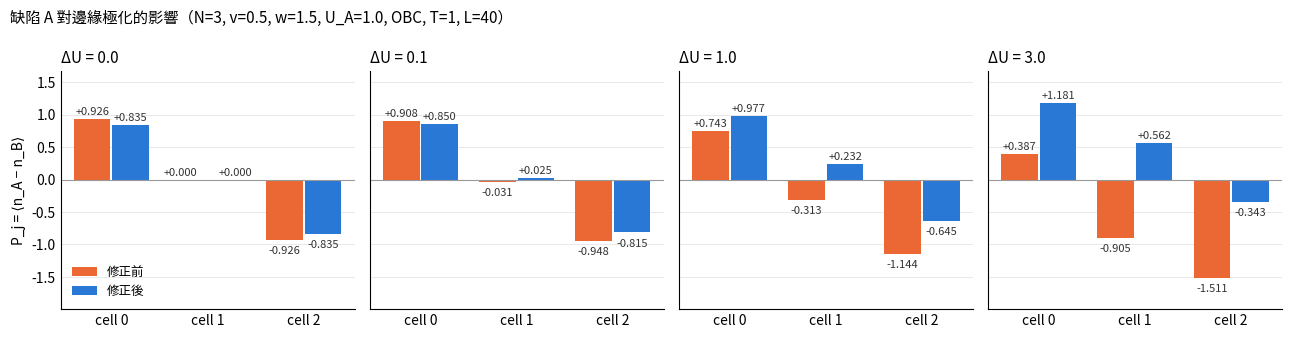

In [6]:
dUs = (0.0, 0.1, 1.0, 3.0)
kw = dict(N_cells=3, total_electrons=8, v=0.5, w=1.5, U_A=1.0, delta_U_values=dUs, T_A=1.0, steps=40, backend=bk)
with patched(core, "_givens_instruction", legacy_givens):
    pol_before = [r["data"]["n_A_minus_n_B"] for r in polarization_sweep(**kw)]
pol_after = [r["data"]["n_A_minus_n_B"] for r in polarization_sweep(**kw)]

table(["ΔU", "修正前 P_j（cell 0,1,2）", "修正後 P_j", "最大變化"],
      [[f"{d}", pol_before[i], pol_after[i], fmt(max(abs(x - y) for x, y in zip(pol_before[i], pol_after[i])))]
       for i, d in enumerate(dUs)])
results["A"]["polarization"] = [{"delta_U": d, "before": pol_before[i], "after": pol_after[i]} for i, d in enumerate(dUs)]

fig, axes = plt.subplots(1, 4, figsize=(13, 3.4), sharey=True)
for ax, d, b, a in zip(axes, dUs, pol_before, pol_after):
    grouped_bars(ax, ["cell 0", "cell 1", "cell 2"], b, a, f"ΔU = {d}", "P_j = ⟨n_A − n_B⟩" if ax is axes[0] else "")
axes[0].legend(frameon=False, fontsize=9, loc="lower left")
fig.suptitle("缺陷 A 對邊緣極化的影響（N=3, v=0.5, w=1.5, U_A=1.0, OBC, T=1, L=40）", x=0.01, ha="left", fontsize=11)
fig.tight_layout(); fig.savefig(FIG_DIR / "A_polarization.svg"); plt.show()

在 $\Delta U=3$ 時中間晶胞的極化從 $-0.905$ 變成 $+0.562$，**正負號翻轉**；兩端的數值也差到 0.8。
凡是用修正前程式產生的極化圖，都需要重新生成。

### 2.5 為什麼 `aqs fidelity` 沒有發現它

`fidelity_scan` 把演化後的態拿來跟**製備態本身**比。製備態錯了，它就一致地跟錯的態比，兩個版本給出幾乎相同的曲線。
自我參照的檢查對「製備了哪一個態」結構上不敏感，這是方法論上的教訓：參考值必須來自程式之外。

In [7]:
fs_kw = dict(N_cells=3, v=0.5, w=1.5, number_of_electrons=6, U=0.0, T_A_values=(1, 5), steps_list=(10, 40), backend=bk)
with patched(core, "_givens_instruction", legacy_givens):
    fs_before = fidelity_scan(**fs_kw)["curves"]
fs_after = fidelity_scan(**fs_kw)["curves"]
max_diff = max(abs(x - y) for T in fs_before for x, y in zip(fs_before[T], fs_after[T]))
table(["T_A", "L", "fidelity_scan 修正前", "修正後"],
      [[str(T), str(L), fmt(fs_before[T][i], 10), fmt(fs_after[T][i], 10)] for T in fs_before for i, L in enumerate((10, 40))])
print(f"兩版本 fidelity_scan 最大差異 = {max_diff:.1e}（只是浮點捨入路徑不同），物理上分不出來。")
results["A"]["fidelity_scan_max_diff"] = max_diff

| T_A | L | fidelity_scan 修正前 | 修正後 |
|---|---|---|---|
| 1.0 | 10 | +0.9909633868 | +0.9909633868 |
| 1.0 | 40 | +0.9994337121 | +0.9994337121 |
| 5.0 | 10 | +0.9834368639 | +0.9834368639 |
| 5.0 | 40 | +0.9984440586 | +0.9984440586 |

兩版本 fidelity_scan 最大差異 = 4.4e-16（只是浮點捨入路徑不同），物理上分不出來。


## 3. 缺陷 B：CUDA-Q 後端把 qubit 順序反過來

### 3.1 缺陷在哪裡

`CudaqBackend.statevector` 把 qiskit 電路轉成 CUDA-Q kernel。舊碼寫道：

```python
# qiskit is little-endian (qubit 0 = LSB); CUDA-Q orders qubit 0 as the
# most-significant bit. Map qiskit qubit i -> CUDA-Q qubit (n-1-i) ...
def cq(qiskit_index):
    return q[n - 1 - qiskit_index]     # <-- 修正前
```

這句註解**一半是對的**：CUDA-Q `sample()` 回傳的**位元字串**確實把 qubit 0 放在最左邊，與 qiskit 相反。
但 `get_state()` 回傳的**態向量振幅索引**是 qubit $q$ 對應第 $q$ 個 bit，**與 qiskit 完全一樣**。
從字串慣例推論索引慣例，就多做了一次反轉。修正後是恆等映射 `q[qiskit_index]`。

### 3.2 直接量測三個 qubit 的慣例

In [8]:
n = 3
rows, xt = [], []
for q in range(n):
    qc = QuantumCircuit(n); qc.x(q)
    idx = int(np.argmax(np.abs(Statevector(qc).data)))
    qiskit_str = format(idx, f"0{n}b")            # qiskit counts：qubit 0 在最右
    cudaq_str = qiskit_str[::-1]                  # CUDA-Q sample：qubit 0 在最左（下方若有 GPU 會實測）
    rows.append([f"X on qubit {q}", str(idx), f"2^{q} = {1 << q}", f"'{qiskit_str}'", f"'{cudaq_str}'"])
    xt.append({"q": q, "index": idx, "qiskit_string": qiskit_str, "cudaq_string": cudaq_str})
table(["電路", "qiskit Statevector 非零索引", "小端序預期", "qiskit counts 字串", "CUDA-Q sample 字串"], rows)
results["B"] = {"x_table": xt}

| 電路 | qiskit Statevector 非零索引 | 小端序預期 | qiskit counts 字串 | CUDA-Q sample 字串 |
|---|---|---|---|---|
| X on qubit 0 | 1 | 2^0 = 1 | '001' | '100' |
| X on qubit 1 | 2 | 2^1 = 2 | '010' | '010' |
| X on qubit 2 | 4 | 2^2 = 4 | '100' | '001' |

In [9]:
# 若本機有 CUDA-Q，實測 get_state() 的索引與 sample() 的字串
live = None
try:
    import cudaq
    cudaq.set_target("qpp-cpu")
    live = []
    for q in range(n):
        k = cudaq.make_kernel(); qb = k.qalloc(n); k.x(qb[q])
        idx = int(np.argmax(np.abs(np.array(cudaq.get_state(k), copy=True).ravel())))
        k2 = cudaq.make_kernel(); qb2 = k2.qalloc(n); k2.x(qb2[q]); k2.mz(qb2)
        s = list(cudaq.sample(k2, shots_count=4))[0]
        live.append({"q": q, "get_state_index": idx, "sample_string": s})
    table(["電路", "CUDA-Q get_state() 非零索引", "CUDA-Q sample() 字串"],
          [[f"X on qubit {r['q']}", str(r["get_state_index"]), f"'{r['sample_string']}'"] for r in live])
    print("實測：get_state() 索引與 qiskit 相同（小端序），sample() 字串則反向。")
except Exception as e:
    print("本機沒有可用的 CUDA-Q，跳過實測：", type(e).__name__)
results["B"]["cudaq_live_x"] = live

| 電路 | CUDA-Q get_state() 非零索引 | CUDA-Q sample() 字串 |
|---|---|---|
| X on qubit 0 | 1 | '100' |
| X on qubit 1 | 2 | '010' |
| X on qubit 2 | 4 | '001' |

實測：get_state() 索引與 qiskit 相同（小端序），sample() 字串則反向。


### 3.3 舊映射對態向量做了什麼

把 qiskit qubit $i$ 接到 CUDA-Q qubit $n-1-i$，再把 CUDA-Q 的態向量原樣回傳，等價於對正確的態向量做**位元反轉置換** $P$。
所以不需要 GPU 就能精確重現舊行為：`舊結果 = 正確結果[P]`。用 `aqs selftest` 的那個 4-qubit 電路來看：

In [10]:
qc = QuantumCircuit(4)
qc.h(0); qc.cx(0, 1); qc.ry(0.7, 2); qc.cx(2, 3); qc.rz(0.3, 1); qc.cx(1, 2); qc.rx(1.1, 0)
ref = np.asarray(Statevector(qc).data)
legacy_cudaq_result = ref[bit_reversal_permutation(4)]       # 舊映射的等價結果
fid_before = fidelity(ref, legacy_cudaq_result)
fid_after_sim = fidelity(ref, bk.statevector(qc))            # 恆等映射（以 qiskit 模擬）

gpu = None
try:
    import cudaq
    ok, gpu = selftest("cudaq")                                # 真實 GPU 後端（修正後程式碼）
except Exception as e:
    print("本機沒有可用的 CUDA-Q，跳過真實 GPU selftest：", type(e).__name__)

table(["", "selftest fidelity"],
      [["修正前（q[n-1-i]，等價於位元反轉）", fmt(fid_before, 8)],
       ["修正後（恆等映射，qiskit 模擬）", fmt(fid_after_sim, 8)],
       ["修正後（真實 CUDA-Q 後端）", fmt(gpu, 8) if gpu is not None else "（無 CUDA-Q，跳過）"]])
results["B"].update({"selftest_before": fid_before, "selftest_after_sim": fid_after_sim, "selftest_after_gpu": gpu})

|  | selftest fidelity |
|---|---|
| 修正前（q[n-1-i]，等價於位元反轉） | +0.18124363 |
| 修正後（恆等映射，qiskit 模擬） | +1.00000000 |
| 修正後（真實 CUDA-Q 後端） | +1.00000000 |

修正前的 fidelity 0.181 就是 `docs/experience.md` 記錄的那個數字；修正後為 1.0。

### 3.4 對物理結果的影響：密度剖面整個顛倒

拿一個真實的 SSH–Hubbard 演化終態（$N=3$、OBC、8 電子、$\Delta U=1$，共 12 個 qubit）來看，
舊映射回傳的態向量算出來的每個 qubit 佔據數會**左右顛倒**：qubit 0（A 格點、自旋上）的密度跑到 qubit 11（B 格點、自旋下）。
自旋區塊互換、格點順序反轉，極化與 Berry 相位都會算在錯的位置上。

| qubit | q0 | q1 | q2 | q3 | q4 | q5 | q6 | q7 | q8 | q9 | q10 | q11 |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| 修正前 ⟨n_q⟩ | +0.917 | +0.594 | +0.487 | +0.603 | +0.455 | +0.944 | +0.917 | +0.594 | +0.487 | +0.603 | +0.455 | +0.944 |
| 修正後 ⟨n_q⟩ | +0.944 | +0.455 | +0.603 | +0.487 | +0.594 | +0.917 | +0.944 | +0.455 | +0.603 | +0.487 | +0.594 | +0.917 |

|  | 極化 P_j（cell 0,1,2） |
|---|---|
| 修正前 | [+0.6449, -0.2325, -0.9771] |
| 修正後 | [+0.9771, +0.2325, -0.6449] |

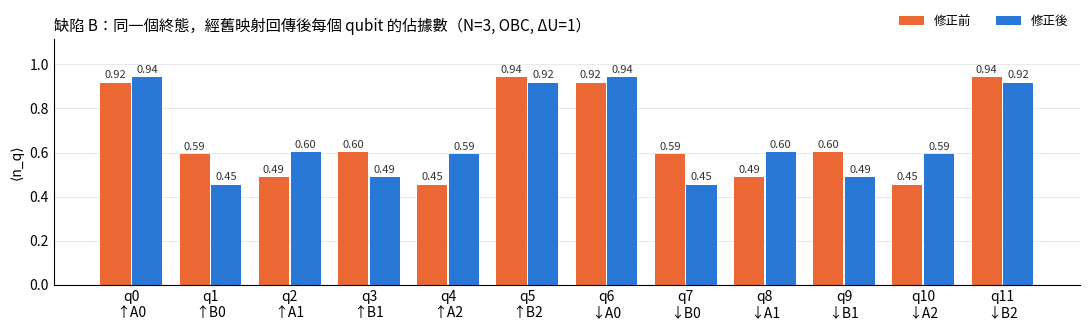

In [11]:
m = SSHHModel.from_total_electrons(3, 0.5, 1.5, 8, PBC=False)
Qu, Qd, _, _ = m.slater_Q_matrices()
qc = build_annealing_circuit(m, Qu, Qd, 1.0, 2.0, T_A=1.0, steps=40, ramp_U=True)
psi_correct = bk.statevector(qc)
psi_legacy = psi_correct[bit_reversal_permutation(12)]
dens_correct = density_profile_qubits(psi_correct, 12)
dens_legacy = density_profile_qubits(psi_legacy, 12)
labels = [f"q{q}\n{'↑' if q < 6 else '↓'}{'A' if q % 2 == 0 else 'B'}{(q % 6)//2}" for q in range(12)]

table(["qubit", *[f"q{q}" for q in range(12)]],
      [["修正前 ⟨n_q⟩", *[fmt(x, 3) for x in dens_legacy]], ["修正後 ⟨n_q⟩", *[fmt(x, 3) for x in dens_correct]]])
pol_legacy = [float(dens_legacy[2*j] + dens_legacy[6+2*j] - dens_legacy[2*j+1] - dens_legacy[6+2*j+1]) for j in range(3)]
pol_correct = [float(dens_correct[2*j] + dens_correct[6+2*j] - dens_correct[2*j+1] - dens_correct[6+2*j+1]) for j in range(3)]
table(["", "極化 P_j（cell 0,1,2）"], [["修正前", pol_legacy], ["修正後", pol_correct]])
results["B"]["density"] = {"labels": labels, "before": [float(x) for x in dens_legacy], "after": [float(x) for x in dens_correct],
                           "pol_before": pol_legacy, "pol_after": pol_correct}

fig, ax = plt.subplots(figsize=(11, 3.4))
grouped_bars(ax, labels, dens_legacy, dens_correct, "缺陷 B：同一個終態，經舊映射回傳後每個 qubit 的佔據數（N=3, OBC, ΔU=1）", "⟨n_q⟩", "{:.2f}")
ax.legend(frameon=False, fontsize=9, loc="lower right", bbox_to_anchor=(1.0, 1.0), ncol=2)
fig.tight_layout(); fig.savefig(FIG_DIR / "B_density.svg"); plt.show()

凡是用 `--backend cudaq` 在修正前跑出的數字，都是從顛倒的態向量算出來的；**全部 GPU 結果都需要重跑**。
對稱的測試態（每個 qubit 密度都一樣）看不出這個問題，這是為什麼 `aqs selftest` 現在刻意用不對稱的電路。

## 4. 缺陷 C：OpenFermion 的大端序沒有轉成 qiskit 的小端序

### 4.1 缺陷在哪裡

`aqs measure` 讀 JSON 哈密頓量時，`fermion_operator` / `qubit_operator` 格式會經過 OpenFermion 的
`get_sparse_operator`。OpenFermion 把模式 $q$ 放在第 $n-1-q$ 個 bit（大端序）；
`observables.PROPERTIES` 裡的所有觀測量則用 qiskit 慣例讀第 $q$ 個 bit（小端序）。
舊的 `load_hamiltonian` 直接把 OpenFermion 的矩陣交出去，於是基態向量的每個 bit 都被反著讀。

修正後多了一步置換相似變換 $H \to P H P^\top$（`_to_little_endian`），只換基底標籤、本徵譜完全不變。
下面用 `patched(ham, "_to_little_endian", 恆等)` 重現舊行為。

In [12]:
identity = lambda H, n: H          # 修正前：不做任何轉換

def write_trapped_chain(n, trap_mode, path, depth=-8.0, hop=-0.2):
    terms = [{"coeff": [depth, 0.0], "ops": f"{trap_mode}^ {trap_mode}"}]
    for i in range(n - 1):
        terms += [{"coeff": [hop, 0.0], "ops": f"{i}^ {i+1}"}, {"coeff": [hop, 0.0], "ops": f"{i+1}^ {i}"}]
    spec = {"type": "hamiltonian", "format": "fermion_operator",
            "metadata": {"n_qubits": n, "n_cells": n // 2, "layout": "spinless"}, "terms": terms}
    json.dump(spec, open(path, "w")); return path

def ground_density(path):
    H, layout, meta = load_hamiltonian(path)
    psi = np.asarray(bk.ground_state(H)).ravel(); psi /= np.linalg.norm(psi)
    return density_profile_qubits(psi, meta["n_qubits"]), np.sort(np.linalg.eigvalsh(H.toarray() if hasattr(H, "toarray") else H))[:3]

### 4.2 診斷例：把粒子關在模式 0

四模式鏈，在模式 0 放一個很深的位能井（$-8$），其餘鍵結只有 $-0.2$。基態的粒子幾乎一定在模式 0，
所以密度 $\langle n_q\rangle$ 應該在 **qubit 0** 最大。這個判斷不依賴程式，只依賴物理。

|  | ⟨n_0⟩ | ⟨n_1⟩ | ⟨n_2⟩ | ⟨n_3⟩ | 密度最大的 qubit | 極化 P_j（cell 0, 1） | 最低三個本徵值 |
|---|---|---|---|---|---|---|---|
| 修正前 | +0.2534 | +0.5022 | +0.2449 | +0.9995 | qubit 3  ✗ | [-0.2488, -0.7546] | [-8.287, -8.284, -8.005] |
| 修正後 | +0.9995 | +0.2449 | +0.5022 | +0.2534 | qubit 0  ✓ | [+0.7546, +0.2488] | [-8.287, -8.284, -8.005] |

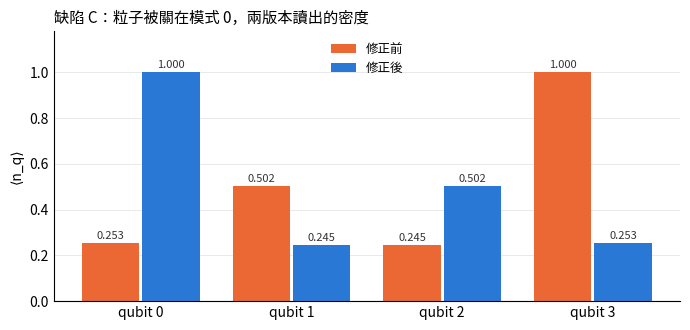

In [13]:
with tempfile.TemporaryDirectory() as d:
    path = write_trapped_chain(4, 0, os.path.join(d, "trap.json"))
    with patched(ham, "_to_little_endian", identity):
        dens_before, eig_before = ground_density(path)
        pol_before_c = measure_hamiltonian(path, ["polarization"], bk)["results"]["polarization"]["n_A_minus_n_B"]
    dens_after, eig_after = ground_density(path)
    pol_after_c = measure_hamiltonian(path, ["polarization"], bk)["results"]["polarization"]["n_A_minus_n_B"]

table(["", "⟨n_0⟩", "⟨n_1⟩", "⟨n_2⟩", "⟨n_3⟩", "密度最大的 qubit", "極化 P_j（cell 0, 1）", "最低三個本徵值"],
      [["修正前", *dens_before, f"qubit {int(np.argmax(dens_before))}  ✗", pol_before_c, fmt(eig_before, 3)],
       ["修正後", *dens_after,  f"qubit {int(np.argmax(dens_after))}  ✓",  pol_after_c,  fmt(eig_after, 3)]])
results["C"] = {"trap": {"before_density": [float(x) for x in dens_before], "after_density": [float(x) for x in dens_after],
                         "before_pol": pol_before_c, "after_pol": pol_after_c,
                         "eig_before": [float(x) for x in eig_before], "eig_after": [float(x) for x in eig_after]}}

fig, ax = plt.subplots(figsize=(7, 3.4))
grouped_bars(ax, [f"qubit {q}" for q in range(4)], dens_before, dens_after, "缺陷 C：粒子被關在模式 0，兩版本讀出的密度", "⟨n_q⟩", "{:.3f}")
ax.legend(frameon=False, fontsize=9, loc="upper center")
fig.tight_layout(); fig.savefig(FIG_DIR / "C_trap_density.svg"); plt.show()

修正前把關在模式 0 的粒子讀成在 qubit 3，整個密度剖面左右顛倒，極化的兩個晶胞**順序反轉且符號相反**；
本徵值兩版本完全相同，所以只看能量是察覺不到的。

### 4.3 為什麼 repo 內附的範例看不出來

`examples/ssh_spinless_N3_*.json` 是半填滿、密度處處 0.5 的均勻鏈。位元反轉對這種對稱分布是恆等操作，
兩個版本給出**一模一樣**的結果。用它們當正確性證據，等於沒測。

In [14]:
rows, ex_rec = [], []
for name in ["ssh_spinless_N3_topological", "ssh_spinless_N3_trivial"]:
    path = REPO / "examples" / f"{name}.json"
    with patched(ham, "_to_little_endian", identity):
        rb = measure_hamiltonian(str(path), ["berry", "polarization"], bk)["results"]
    ra = measure_hamiltonian(str(path), ["berry", "polarization"], bk)["results"]
    rows.append([name, fmt(rb["berry"]["Twist_Amplitude"], 6), fmt(ra["berry"]["Twist_Amplitude"], 6),
                 fmt(max(abs(x) for x in rb["polarization"]["n_A_minus_n_B"]), 6),
                 fmt(max(abs(x) for x in ra["polarization"]["n_A_minus_n_B"]), 6)])
    ex_rec.append({"name": name, "z_before": rb["berry"]["Twist_Amplitude"], "z_after": ra["berry"]["Twist_Amplitude"],
                   "max_pol_before": max(abs(x) for x in rb["polarization"]["n_A_minus_n_B"]),
                   "max_pol_after": max(abs(x) for x in ra["polarization"]["n_A_minus_n_B"])})
table(["範例", "|z_N| 修正前", "|z_N| 修正後", "max|P_j| 修正前", "max|P_j| 修正後"], rows)
results["C"]["examples"] = ex_rec

| 範例 | |z_N| 修正前 | |z_N| 修正後 | max|P_j| 修正前 | max|P_j| 修正後 |
|---|---|---|---|---|
| ssh_spinless_N3_topological | +0.030338 | +0.030338 | +0.000000 | +0.000000 |
| ssh_spinless_N3_trivial | +0.958801 | +0.958801 | +0.000000 | +0.000000 |

### 4.4 複數躍遷：實部看不到、虛部被共軛

更隱蔽的一層：對兩個模式做大端序↔小端序轉換等於交換兩個模式的標籤，這會把非對角元 $-t$ 換成 $-t^{*}$。
躍遷是實數時毫無差別；一旦 $t$ 有虛部（例如加了磁通或 Peierls 相位），舊碼交出去的哈密頓量**虛部符號是反的**，
而本徵值仍然一樣。任何涉及 $\mathrm{Im}(t)$ 的推導都必須先轉換再比對。

In [15]:
t = 0.7 + 0.45j
op = of.FermionOperator("0^ 1", -t) + of.FermionOperator("1^ 0", -np.conj(t))
H_before = of.get_sparse_operator(op, n_qubits=2).toarray()
H_after = ham._to_little_endian(H_before, 2)
table(["", "H[|01⟩,|10⟩]（q0 佔據 → q1 佔據）", "本徵值"],
      [["修正前（OpenFermion 原樣）", fmt(H_before[1, 2]), fmt(np.linalg.eigvalsh(H_before), 4)],
       ["修正後（_to_little_endian）", fmt(H_after[1, 2]), fmt(np.linalg.eigvalsh(H_after), 4)],
       ["應得  −t", fmt(-t), ""]])
results["C"]["complex"] = {"t": [t.real, t.imag], "before_offdiag": [H_before[1, 2].real, H_before[1, 2].imag],
                           "after_offdiag": [H_after[1, 2].real, H_after[1, 2].imag],
                           "eig": [float(x) for x in np.linalg.eigvalsh(H_after)]}

|  | H[|01⟩,|10⟩]（q0 佔據 → q1 佔據） | 本徵值 |
|---|---|---|
| 修正前（OpenFermion 原樣） | -0.7000+0.4500i | [-0.8322, +0.0000, +0.0000, +0.8322] |
| 修正後（_to_little_endian） | -0.7000-0.4500i | [-0.8322, +0.0000, +0.0000, +0.8322] |
| 應得  −t | -0.7000-0.4500i |  |

## 5. 總結

| | 缺陷 | 修正前的錯法 | 誰會受影響 | 怎麼確認自己沒踩到 |
|---|---|---|---|---|
| **A** | Givens 反號 | 製備出最高能帶的行列式態，能量 $+E$ | `aqs polarization`（極化翻號）、$\Delta U\neq0$ 的 `aqs berry`；`aqs fidelity` 看不出來 | 製備態 $\langle H\rangle$ 必須等於最低填充 $\sum\varepsilon$ |
| **B** | CUDA-Q 反轉 | 態向量位元反轉，密度剖面顛倒 | **所有** `--backend cudaq` 結果 | `aqs selftest --backend cudaq` 必須 fidelity 1.0（用不對稱電路） |
| **C** | OpenFermion 端序 | 非對稱哈密頓量的觀測量讀在錯的 qubit，複數躍遷虛部共軛 | `aqs measure` 的 `fermion_operator`/`qubit_operator` 格式 | 陷阱模式測試：粒子關在模式 $m$ 要從 qubit $m$ 讀出 |

### 合併後需要重新產生的結果

1. 所有極化圖（缺陷 A；$\Delta U=3$ 時中間晶胞翻號）。
2. 所有在 GPU 上用 `--backend cudaq` 得到的數字（缺陷 B）。
3. 任何以 `aqs measure` 讀入非均勻密度哈密頓量的結果（缺陷 C）。內附的兩個均勻範例不受影響。

### 給 `QCE26/` 的提醒

`origin/main` 上 `QCE26/src/aqs/` 內的 `core.py`、`hamiltonian.py`、`backends.py` 與修正前版本逐位元相同，
`cudaq_core.py` 也使用 $n-1-i$ 映射。用那個目錄產生的數字，會同時帶有 A、B、C 三個缺陷。

### 三個守門測試（本分支 `tests/`）

- `test_state_preparation.py`：缺陷 A，把 `cry(-2θ)` 放回去會有 4/6 個測試變紅。
- `test_backend_endianness.py`：缺陷 B，把 `q[n-1-i]` 放回去 selftest 掉到 0.181。
- `test_hamiltonian_endianness.py`：缺陷 C，拿掉 `_to_little_endian` 陷阱測試 4 個模式全部讀錯。

In [16]:
# 匯出給 Typst 摘要使用
with open(OUT_DIR / "results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)
print("wrote", OUT_DIR / "results.json")
print("figures:", sorted(p.name for p in FIG_DIR.glob("*.svg")))

wrote /mnt/sata/b11202015/Adiabatic-Quantum-Simulation/docs/defect_report/results.json
figures: ['A_polarization.svg', 'B_density.svg', 'C_trap_density.svg']
